# 03 · Financial Markets — An Honest Negative

We now point the exact machine at the stock market. The result is a *failure* — and
it is one of the most important results in the whole programme, because it is
honest, it is measured against controls, and it reshapes the question we ask for the
rest of the series.

The plan: binarise daily prices into up/down, and ask the same thing we asked of the
yeast network — *is there a deterministic rule?* We will see there is not, and we
will prove it is not a bug in our method by running a system that **does** have a
rule (a cellular automaton) through the identical test.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. Turn prices into bits

For each day and each stock we write **1 if it rose, 0 if it fell**. A row is one
day; a column is one stock. This is the crudest possible encoding — and the one
every earlier level quietly assumed.

9 stocks, 752 trading days


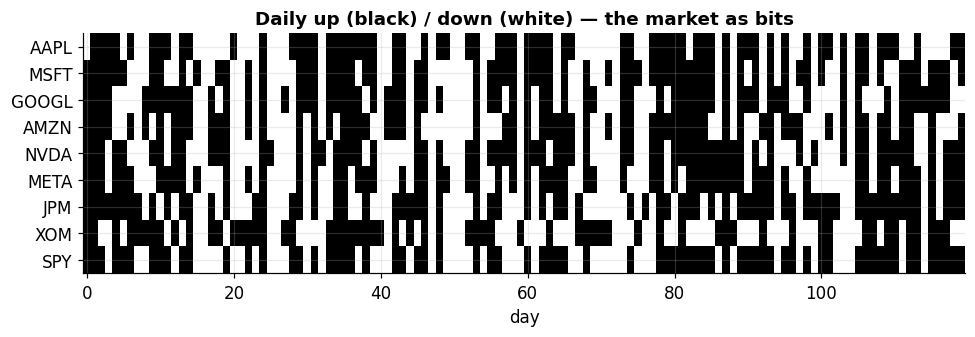

In [2]:
from finance import align_prices, to_binary_states
import glob

tickers = ["AAPL","MSFT","GOOGL","AMZN","NVDA","META","JPM","XOM","SPY"]
paths = {t: os.path.join(DATA, f"{t}.json") for t in tickers if os.path.exists(os.path.join(DATA, f"{t}.json"))}
names, dates, M = align_prices(paths)
states = to_binary_states(M)                # list of daily up/down vectors
S = np.array(states)
print(f"{len(names)} stocks, {len(S)} trading days")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.imshow(S[:120].T, cmap="binary", aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("day"); ax.set_title("Daily up (black) / down (white) — the market as bits")
plt.tight_layout(); plt.show()

## 2. Is there a deterministic rule? The contradiction test

If tomorrow's direction were a fixed function of today's pattern, then whenever the
**same** predictor pattern recurs it must give the **same** answer. We count the
fraction of recurring patterns that give *both* answers — the **contradiction
rate**. Zero means deterministic; high means intrinsically unpredictable.

We run two systems through the identical analyser: the market, and a rule-110
cellular automaton (which we *know* is deterministic).

In [3]:
from finance import analyse
from ca_deconvolution import evolve_eca
import random

# market
market = analyse(states, max_k=2)

# deterministic control: a rule-110 CA of the same shape
rng = random.Random(0)
w = len(names)
ca_rows = evolve_eca(110, [rng.randint(0,1) for _ in range(w)], len(states)+1)
ca = analyse(ca_rows, max_k=3)

print(f"{'':22s}{'contradiction':>14s}{'best acc':>10s}{'base rate':>11s}{'exact nodes':>12s}")
for label, a in [("MARKET (real)", market), ("rule-110 CA (control)", ca)]:
    print(f"{label:22s}{a['mean_contradiction_rate']:>14.3f}{a['mean_best_accuracy']:>10.3f}"
          f"{a['mean_base_rate']:>11.3f}{a['exact_nodes']:>9d}/{a['n_nodes']}")

                       contradiction  best acc  base rate exact nodes
MARKET (real)                  0.663     0.562      0.541        0/9
rule-110 CA (control)          0.000     1.000      0.699        9/9


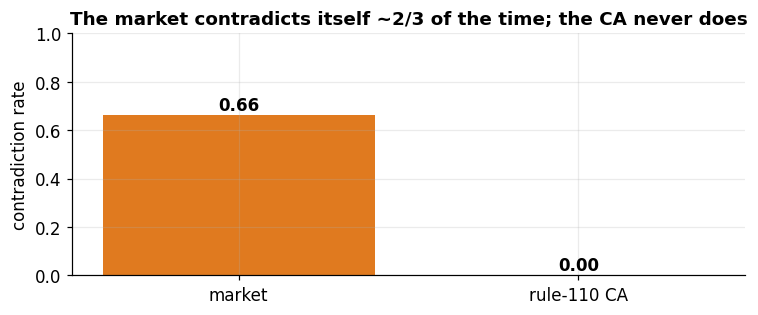

Same analyser. It recovers the CA as fully deterministic and shows the market is not.


In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["market", "rule-110 CA"], [market["mean_contradiction_rate"], ca["mean_contradiction_rate"]],
       color=[BAD, OK])
ax.set_ylabel("contradiction rate"); ax.set_ylim(0, 1)
ax.set_title("The market contradicts itself ~2/3 of the time; the CA never does")
for i, v in enumerate([market["mean_contradiction_rate"], ca["mean_contradiction_rate"]]):
    ax.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print("Same analyser. It recovers the CA as fully deterministic and shows the market is not.")

## 3. Direction is not predictable out of sample

Best small rule beats "always guess the common direction" by only ~2 percentage
points *in sample* — and that edge vanishes out of sample. There is no directional
money to be made here, and we will keep finding this at every later level.

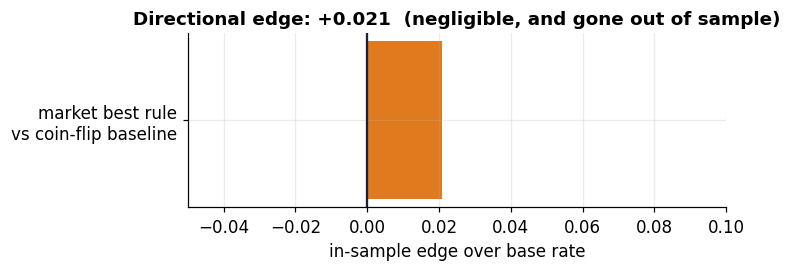

In [5]:
lift = market["mean_lift_over_base"]
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["market best rule\nvs coin-flip baseline"], [lift], color=BAD if lift < 0.05 else OK)
ax.axvline(0, color=INK); ax.set_xlim(-0.05, 0.1); ax.set_xlabel("in-sample edge over base rate")
ax.set_title(f"Directional edge: +{lift:.3f}  (negligible, and gone out of sample)")
plt.tight_layout(); plt.show()

## 4. Why the whole-pattern view also fails

One might try to predict the *whole* daily pattern from yesterday's whole pattern.
But the market almost never repeats an exact configuration, so there is nothing to
look up.

In [6]:
patterns = [tuple(row) for row in states]
distinct = len(set(patterns))
recurring = sum(1 for p in set(patterns) if patterns.count(p) > 1)
print(f"{len(patterns)} days, {distinct} distinct daily patterns, only {recurring} ever recur.")
print(f"space of possible patterns: 2**{len(names)} = {2**len(names):,}")
print("With essentially no repeats, no configuration-to-configuration map can generalise.")

752 days, 285 distinct daily patterns, only 141 ever recur.
space of possible patterns: 2**9 = 512
With essentially no repeats, no configuration-to-configuration map can generalise.


## Takeaways — and the turn

* The market carries **no deterministic rule** at the daily up/down scale: two-thirds
  of recurring patterns contradict themselves, and no directional edge survives.
* This is not our method failing — the *same* analyser recovers a cellular automaton
  as perfectly deterministic. It is an honest property of the data.
* **Direction is unpredictable.** We will never forget this.

But there was one crack of light (found later): the *irregularity* of the market is
not spread evenly in time. That hint — order in **where** structure falls, not in a
global rule — drives everything from here on.

**Next (04):** we stop assuming up/down is the right encoding, look at the *size* of
moves, and find the first real, self-similar signal.